<a href="https://colab.research.google.com/github/ngzhiwei517/Fetal-Distress-Detection/blob/main/Fetal_distress_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1️ Data Exploration & Understanding

In [2]:
import pandas as pd
df=pd.read_csv('/content/CTG.csv')
df.head()

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,1/12/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,3/5/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,3/5/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,3/5/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,3/5/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


In [3]:
df.iloc[0] #index 0

,0
FileName,Variab10.txt
Date,1/12/1996
SegFile,CTG0001.txt
b,240.0
e,357.0
LBE,120.0
LB,120.0
AC,0.0
FM,0.0
UC,0.0


In [4]:
df = df.iloc[1:].reset_index(drop=True)
df

,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Fmcs_1.txt,3/5/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
1,Fmcs_1.txt,3/5/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,3/5/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,3/5/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
4,Fmcs_2.txt,3/5/1996,CTG0006.txt,0.0,953.0,134.0,134.0,1.0,0.0,10.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,8.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2123,S8001045.dsp,6/6/1998,CTG2127.txt,1576.0,3049.0,140.0,140.0,1.0,0.0,9.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2124,S8001045.dsp,6/6/1998,CTG2128.txt,2796.0,3415.0,142.0,142.0,1.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2126,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(2128, 40)

In [6]:
df.columns

Index(['FileName', 'Date', 'SegFile', 'b', 'e', 'LBE', 'LB', 'AC', 'FM', 'UC',
       'ASTV', 'MSTV', 'ALTV', 'MLTV', 'DL', 'DS', 'DP', 'DR', 'Width', 'Min',
       'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance',
       'Tendency', 'A', 'B', 'C', 'D', 'E', 'AD', 'DE', 'LD', 'FS', 'SUSP',
       'CLASS', 'NSP'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2128 entries, 0 to 2127
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FileName  2125 non-null   object 
 1   Date      2125 non-null   object 
 2   SegFile   2125 non-null   object 
 3   b         2125 non-null   float64
 4   e         2125 non-null   float64
 5   LBE       2125 non-null   float64
 6   LB        2125 non-null   float64
 7   AC        2125 non-null   float64
 8   FM        2126 non-null   float64
 9   UC        2126 non-null   float64
 10  ASTV      2126 non-null   float64
 11  MSTV      2126 non-null   float64
 12  ALTV      2126 non-null   float64
 13  MLTV      2126 non-null   float64
 14  DL        2127 non-null   float64
 15  DS        2127 non-null   float64
 16  DP        2127 non-null   float64
 17  DR        2127 non-null   float64
 18  Width     2125 non-null   float64
 19  Min       2125 non-null   float64
 20  Max       2125 non-null   floa

Many columns that should be numeric are currently of type object:

Examples:

LB (baseline heart rate)

AC, FM, UC

In [8]:
df.isna().sum()

,0
FileName,3
Date,3
SegFile,3
b,3
e,3
LBE,3
LB,3
AC,3
FM,2
UC,2


In [9]:
df['NSP'].value_counts().sort_index()

,count
NSP,
1.0,1655
2.0,294
3.0,176


Key observations

Highly imbalanced dataset

Normal ≈ 78%

Suspect ≈ 14%

Pathologic ≈ 8%

The dataset exhibits strong class imbalance, with Normal cases dominating. Therefore, stratified splitting was used during train–test split and cross-validation to ensure consistent class representation across folds.



---


Doctors’ CTG flow:

Baseline

Variability

Accelerations

Decelerations

Overall pattern

# ① Baseline (LB)

## LB — Histogram

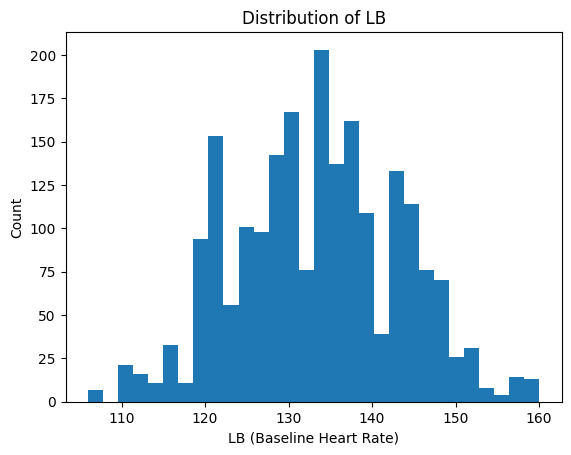

In [10]:
import matplotlib.pyplot as plt

lb = pd.to_numeric(df['LB'], errors='coerce')

plt.figure()
plt.hist(lb.dropna(), bins=30)
plt.xlabel('LB (Baseline Heart Rate)')
plt.ylabel('Count')
plt.title('Distribution of LB')
plt.show()


Observation from the histogram

* Most LB values cluster between 120–145 bpm

* The distribution is roughly bell-shaped, centered around ~130–140 bpm

EDA interpretation
* The majority of samples lie within the clinically normal range (110–160 bpm)

## LB vs NSP — Boxplot

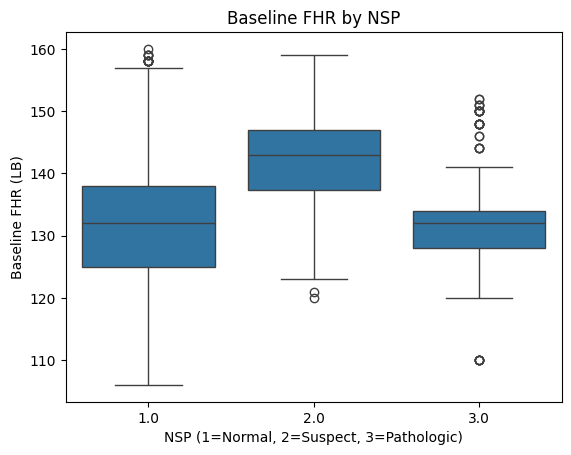

In [11]:
import seaborn as sns

plt.figure()
sns.boxplot(x='NSP', y=lb, data=df.assign(LB_num=lb))
plt.xlabel('NSP (1=Normal, 2=Suspect, 3=Pathologic)')
plt.ylabel('Baseline FHR (LB)')
plt.title('Baseline FHR by NSP')
plt.show()


# ② Variability (ASTV / ALTV)

## ASTV vs NSP

Text(0.5, 1.0, 'Abnormal Short-Term Variability by NSP')

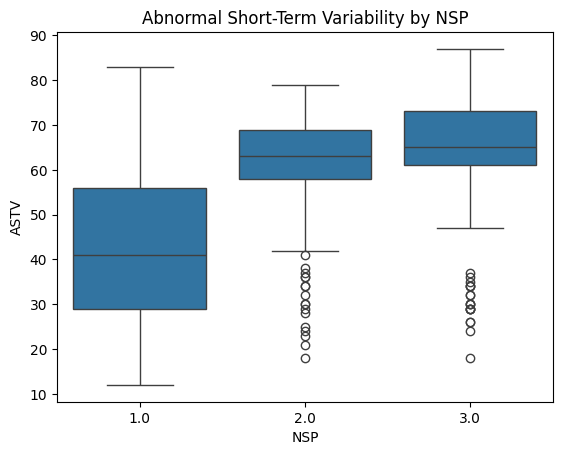

In [12]:
astv = pd.to_numeric(df['ASTV'], errors='coerce')

plt.figure()
sns.boxplot(x='NSP', y=astv, data=df.assign(ASTV_num=astv))
plt.xlabel('NSP')
plt.ylabel('ASTV')
plt.title('Abnormal Short-Term Variability by NSP')


## ALTV vs NSP

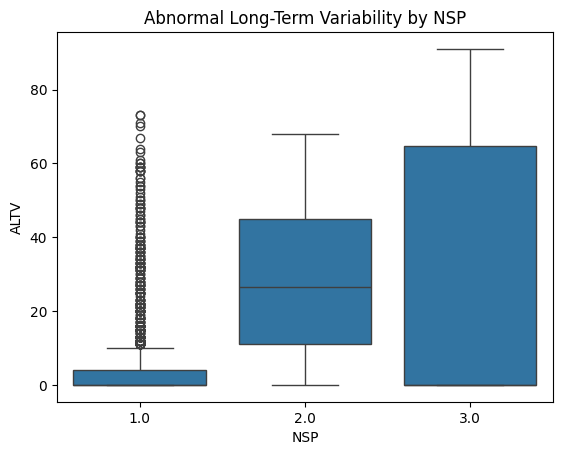

In [13]:
altv = pd.to_numeric(df['ALTV'], errors='coerce')

plt.figure()
sns.boxplot(x='NSP', y=altv, data=df.assign(ALTV_num=altv))
plt.xlabel('NSP')
plt.ylabel('ALTV')
plt.title('Abnormal Long-Term Variability by NSP')
plt.show()


What we see

NSP = 1 (Normal)

* Median ≈ 0

* Very tight IQR near 0

* Many outliers, but core distribution is low

NSP = 2 (Suspect)

* Median shifts upward (~25)

* Wider IQR

NSP = 3 (Pathologic)
* Median much higher
* Very large spread


---


Clinical interpretation

* Normal babies show stable long-term rhythm
* Pathologic cases show highly abnormal long-term variability
* This matches medical intuition perfectly


---


EDA takeaway (important)

* ALTV strongly separates Normal, Suspect, and Pathologic cases.

##



---

EDA shows that abnormal variability features are the strongest indicators of fetal distress. ALTV increases consistently from Normal to Pathologic cases, while ASTV exhibits a non-linear pattern: reduced variability in Suspect cases and erratic variability in Pathologic cases. These findings align with clinical CTG interpretation and suggest that non-linear models are better suited for this task.

### “EDA revealed non-linear, class-dependent variability patterns, so tree-based models were chosen.”

# ③ Accelerations (AC)

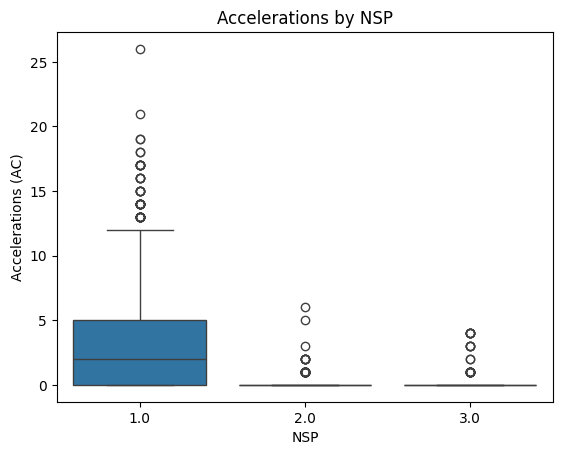

In [14]:
ac = pd.to_numeric(df['AC'], errors='coerce')

plt.figure()
sns.boxplot(x='NSP', y=ac, data=df.assign(AC_num=ac))
plt.xlabel('NSP')
plt.ylabel('Accelerations (AC)')
plt.title('Accelerations by NSP')
plt.show()


Normal cases show higher and more frequent accelerations, with a wider spread of AC values. In contrast, Suspect and Pathologic cases have AC values concentrated near zero, indicating fewer or absent accelerations

* This clear separation suggests that accelerations are a strong discriminative feature between Normal and non-Normal fetal states.

# ④ Decelerations (DS, DP)

## DS vs NSP

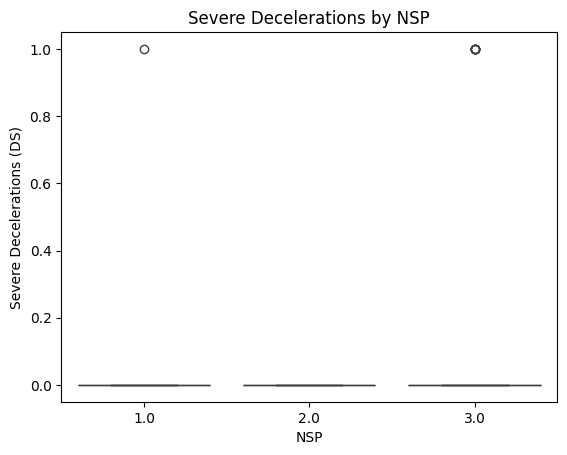

In [15]:
ds = pd.to_numeric(df['DS'], errors='coerce')

plt.figure()
sns.boxplot(x='NSP', y=ds, data=df.assign(DS_num=ds))
plt.xlabel('NSP')
plt.ylabel('Severe Decelerations (DS)')
plt.title('Severe Decelerations by NSP')
plt.show()


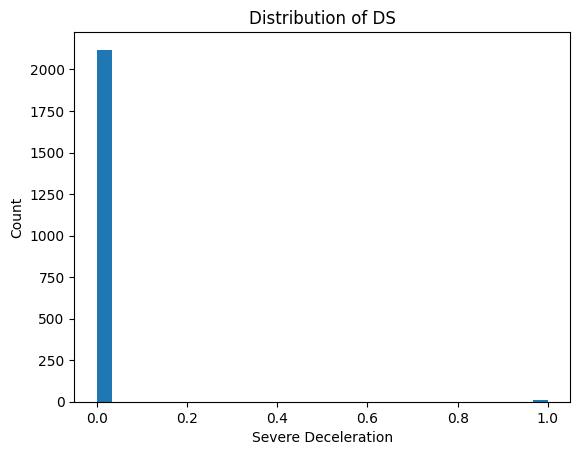

In [16]:
import matplotlib.pyplot as plt

ds = pd.to_numeric(df['DS'], errors='coerce')

plt.figure()
plt.hist(ds.dropna(), bins=30)
plt.xlabel('Severe Deceleration')
plt.ylabel('Count')
plt.title('Distribution of DS')
plt.show()


## DP vs NSP

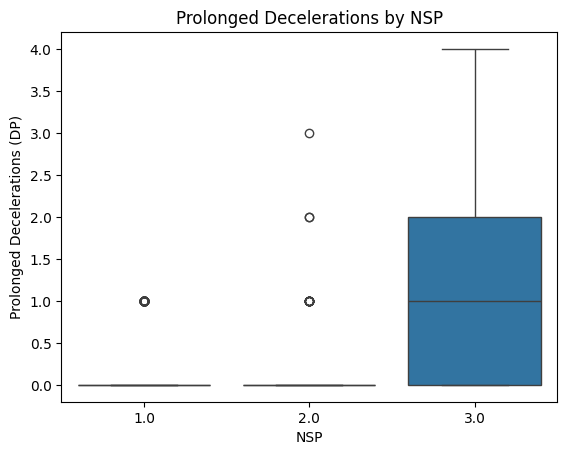

In [17]:
dp = pd.to_numeric(df['DP'], errors='coerce')

plt.figure()
sns.boxplot(x='NSP', y=dp, data=df.assign(DP_num=dp))
plt.xlabel('NSP')
plt.ylabel('Prolonged Decelerations (DP)')
plt.title('Prolonged Decelerations by NSP')
plt.show()


**Prolonged Decelerations (DP)**

Normal cases show almost no prolonged decelerations, with values concentrated at zero. Suspect cases show occasional occurrences, while Pathologic cases have higher DP values and a wider spread.

This pattern indicates that prolonged decelerations are strongly associated with pathological fetal states

# ⑤ Summary — Correlation with Target

### Correlation Heatmap (NSP only)

In [18]:
# Columns that are identifiers (NOT medical signals)
id_cols = ['FileName', 'Date', 'SegFile']

# Columns that are medical measurements but loaded as object
to_numeric_cols = [
    'b','e','LBE','LB','AC','FM','UC','DL','DS','DP',
    'Width','Nmax'
]

df[to_numeric_cols] = df[to_numeric_cols].apply(
    pd.to_numeric, errors='coerce'
)



In [19]:
exclude_cols = ['FileName', 'Date', 'SegFile', 'CLASS']
features = df.drop(columns=exclude_cols)
corr_nsp = (
    features
    .select_dtypes(include='number')
    .corrwith(df['NSP'], method='spearman')
    .sort_values()
)


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


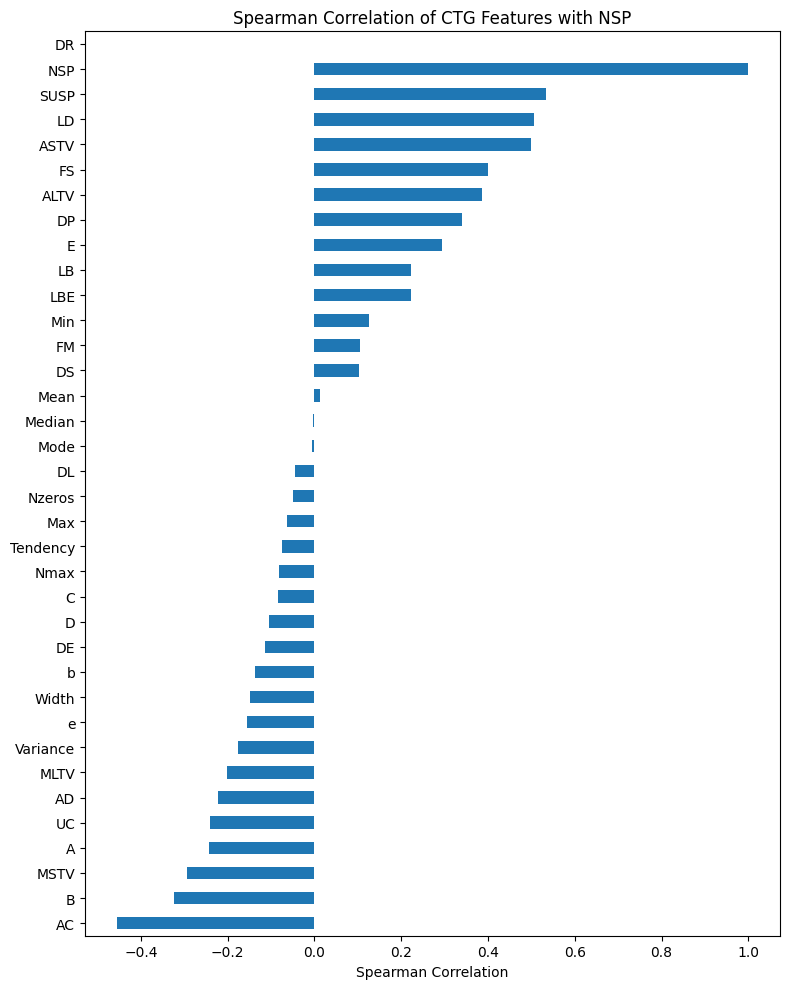

In [20]:
plt.figure(figsize=(8, 10))
corr_nsp.plot(kind='barh')
plt.title('Spearman Correlation of CTG Features with NSP')
plt.xlabel('Spearman Correlation')
plt.tight_layout()
plt.show()


* Baseline heart rate (LB) shows only a moderate correlation, indicating that average heart rate alone is insufficient to determine fetal condition

* Variability-related features (e.g. ASTV, ALTV, ) show stronger correlations with fetal outcome compared to baseline heart rate alone.



* Accelerations (AC) show a negative correlation with NSP, suggesting that more accelerations are associated with healthier (Normal) outcomes.

* Deceleration-related features (DP, DS, DL) are positively associated with worse fetal outcomes, supporting their role as clinical risk indicators.



> No single feature dominates the outcome; instead, fetal status appears to be influenced by a combination of variability, accelerations, and deceleration patterns, which aligns with clinical CTG interpretation.


In [21]:
key_features = [
    'LB','AC','FM','UC','DL','DS','DP',
    'ASTV','ALTV','Variance','Width','CLASS'
]

corr_key = df[key_features].corr()


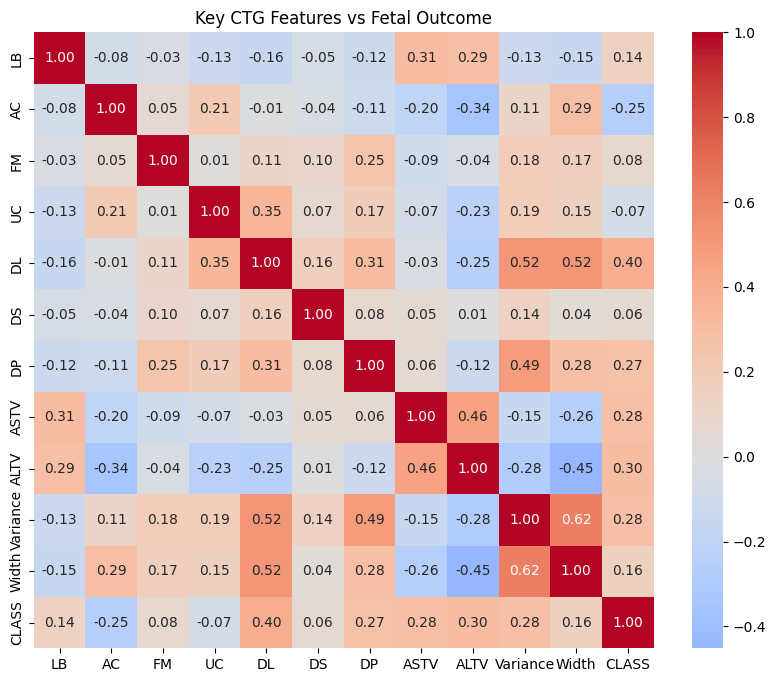

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_key,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0
)
plt.title('Key CTG Features vs Fetal Outcome')
plt.show()


# Step 2️ Data Cleaning & Preprocessing



*   Handle null value
*   Scaling and normalising
*   One hot encoding/mapping



### Check & handle missing values

In [23]:
df.isnull().sum()

,0
FileName,3
Date,3
SegFile,3
b,3
e,3
LBE,3
LB,3
AC,3
FM,2
UC,2


In [24]:
df=df.dropna()
df.isna().sum()

,0
FileName,0
Date,0
SegFile,0
b,0
e,0
LBE,0
LB,0
AC,0
FM,0
UC,0


### Separate features and target

In [25]:
cols_to_drop = [
    "Date", "SegFile", "FileName",'NMAX','Nzeros','Tendency','LBE',
    "b", "e", "A", "B", "C", "D", "E",'AD','DE','LD','FS','CLASS','NSP'
]

X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
y = df["NSP"]

In [26]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2125 entries, 0 to 2124
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2125 non-null   float64
 1   AC        2125 non-null   float64
 2   FM        2125 non-null   float64
 3   UC        2125 non-null   float64
 4   ASTV      2125 non-null   float64
 5   MSTV      2125 non-null   float64
 6   ALTV      2125 non-null   float64
 7   MLTV      2125 non-null   float64
 8   DL        2125 non-null   float64
 9   DS        2125 non-null   float64
 10  DP        2125 non-null   float64
 11  DR        2125 non-null   float64
 12  Width     2125 non-null   float64
 13  Min       2125 non-null   float64
 14  Max       2125 non-null   float64
 15  Nmax      2125 non-null   float64
 16  Mode      2125 non-null   float64
 17  Mean      2125 non-null   float64
 18  Median    2125 non-null   float64
 19  Variance  2125 non-null   float64
 20  SUSP      2125 non-null   float64
d

### Stratified train–test split

Due to the imbalanced class distribution, stratified splitting was used to maintain similar class proportions in both training and testing sets, ensuring fair and reliable evaluation.

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Encode target labels (safety check)

In [28]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

### Feature scaling

Why StandardScaler

* Works well with normally distributed features

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [30]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)


(1700, 21)
(425, 21)


Data preprocessing involved removing non-observational rows, handling missing values via deletion, performing stratified train–test splitting, and applying feature scaling while preventing data leakage.

# Step 3️ Baseline Models

### Baseline Model 1 — Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    recall_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Normal", "Suspect", "Pathologic"]
))

bal_acc = balanced_accuracy_score(y_test, y_pred_lr)

print("Balanced Accuracy:", bal_acc)

              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       331
     Suspect       0.93      0.68      0.78        59
  Pathologic       0.88      0.86      0.87        35

    accuracy                           0.93       425
   macro avg       0.92      0.84      0.87       425
weighted avg       0.93      0.93      0.93       425

Balanced Accuracy: 0.8400010728855012


Overall accuracy looks strong (0.93)
* 93% accuracy seems excellent at first glance.
* But this is heavily influenced by the majority class (Normal = 331 samples).

So accuracy is slightly optimistic here.

Balanced accuracy tells the real story (0.84)
* Balanced accuracy = 0.84
* This drops because it treats each class equally.

So the model is:
* very good on Normal
* weaker on minority classes

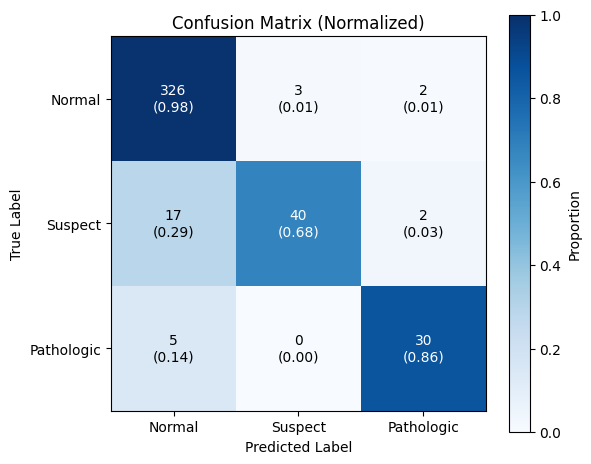

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

class_names = ["Normal", "Suspect", "Pathologic"]

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# optional: normalize by true labels
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.title("Confusion Matrix (Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        plt.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]:.2f})",
            ha="center", va="center",
            color=color
        )

plt.colorbar(label="Proportion")
plt.tight_layout()
plt.show()



### Baseline Model 2 — Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42

)

rf.fit(X_train_scaled, y_train)  # scaled data is OK

y_pred_rf = rf.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report


print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["Normal", "Suspect", "Pathologic"]
))


              precision    recall  f1-score   support

      Normal       0.94      0.99      0.96       332
     Suspect       0.93      0.64      0.76        59
  Pathologic       0.86      0.89      0.87        35

    accuracy                           0.93       426
   macro avg       0.91      0.84      0.87       426
weighted avg       0.93      0.93      0.93       426



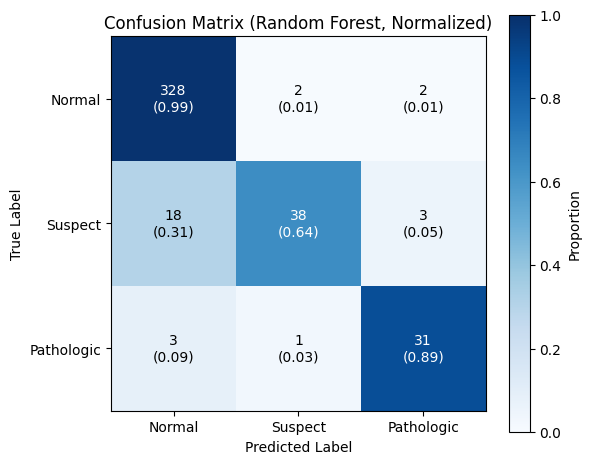

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

class_names = ["Normal", "Suspect", "Pathologic"]

# compute confusion matrix for RF
cm = confusion_matrix(y_test, y_pred_rf)

# normalize by rows
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.title("Confusion Matrix (Random Forest, Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        plt.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]:.2f})",
            ha="center", va="center",
            color=color
        )

plt.colorbar(label="Proportion")
plt.tight_layout()
plt.show()


### Baseline model 3 -XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    use_label_encoder=False
)

y_train_xgb = y_train - 1
y_test_xgb  = y_test  - 1

xgb.fit(X_train_scaled, y_train_xgb)
y_pred_xgb = xgb.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:05:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost is not a sklearn model. So we do not have class weight='balanced' here

In [ ]:
from sklearn.metrics import classification_report

# Add 1 back to predictions to match original labels
y_pred_xgb_original = y_pred_xgb + 1

print("XGBoost")
print(classification_report(
    y_test,
    y_pred_xgb_original,
    target_names=["Normal", "Suspect", "Pathologic"]
))

XGBoost
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       332
     Suspect       0.92      0.78      0.84        59
  Pathologic       0.91      0.91      0.91        35

    accuracy                           0.95       426
   macro avg       0.93      0.89      0.91       426
weighted avg       0.95      0.95      0.95       426



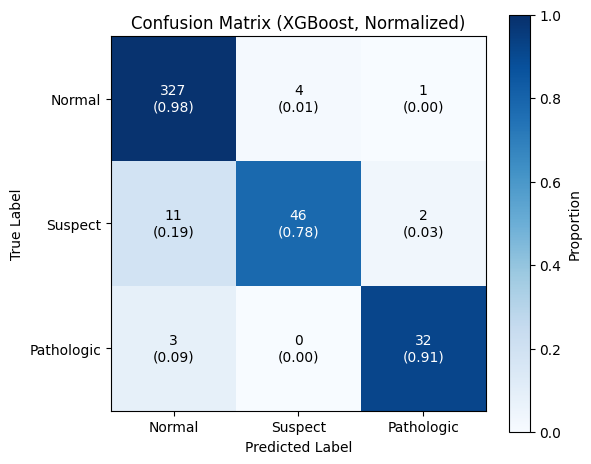

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

class_names = ["Normal", "Suspect", "Pathologic"]

# Compute confusion matrix for XGBoost
cm = confusion_matrix(y_test, y_pred_xgb_original)

# Normalize by rows
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.title("Confusion Matrix (XGBoost, Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        plt.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]:.2f})",
            ha="center", va="center",
            color=color
        )

plt.colorbar(label="Proportion")
plt.tight_layout()
plt.show()

### Baseline model 4 -SVM

In [ ]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    random_state=42
)

svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)

In [ ]:
# Classification Report for SVM
print("SVM")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Normal", "Suspect", "Pathologic"]
))


SVM
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.96       332
     Suspect       1.00      0.64      0.78        59
  Pathologic       0.91      0.86      0.88        35

    accuracy                           0.94       426
   macro avg       0.95      0.83      0.88       426
weighted avg       0.94      0.94      0.93       426



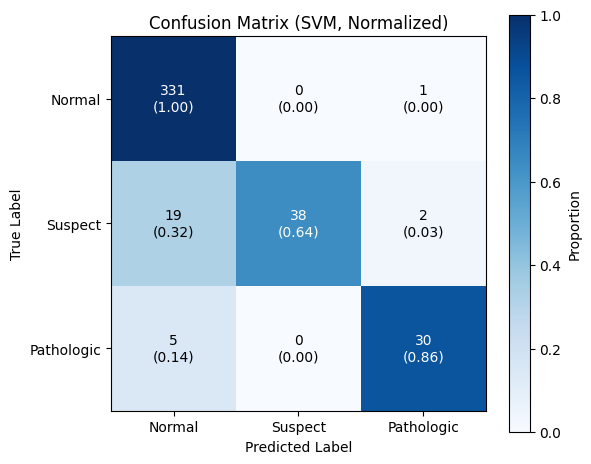

In [ ]:
cm = confusion_matrix(y_test, y_pred_svm)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
plt.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
plt.title("Confusion Matrix (SVM, Normalized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm_norm[i, j] > 0.5 else "black"
        plt.text(
            j, i,
            f"{cm[i, j]}\n({cm_norm[i, j]:.2f})",
            ha="center", va="center",
            color=color
        )

plt.colorbar(label="Proportion")
plt.tight_layout()
plt.show()

# Step 4️ K-Fold Cross-Validation (Model Selection)

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, f1_score
import numpy as np

# Define 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=42,
        use_label_encoder=False
    ),
    'SVM': SVC(kernel='rbf', random_state=42)
}


In [ ]:
cv_results = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Evaluating {name}...")
    print(f"{'='*50}")

    # Prepare labels for XGBoost (0-indexed)
    if name == 'XGBoost':
        y_cv = y_train - 1
    else:
        y_cv = y_train

    ba_scores = cross_val_score(
        model, X_train_scaled, y_cv,
        cv=cv,
        scoring='balanced_accuracy',
        n_jobs=-1
    )


    f1_scores = cross_val_score(
        model, X_train_scaled, y_cv,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1
    )

    cv_results[name] = {
        'balanced_accuracy': ba_scores,
        'f1_macro': f1_scores,
        'ba_mean': ba_scores.mean(),
        'ba_std': ba_scores.std(),
        'f1_mean': f1_scores.mean(),
        'f1_std': f1_scores.std()
    }

    print(f"Balanced Accuracy: {ba_scores.mean():.4f} (+/- {ba_scores.std():.4f})")
    print(f"Macro F1-Score:    {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")


Evaluating LogisticRegression...
Balanced Accuracy: 0.8799 (+/- 0.0149)
Macro F1-Score:    0.9013 (+/- 0.0174)

Evaluating RandomForest...
Balanced Accuracy: 0.9049 (+/- 0.0186)
Macro F1-Score:    0.9274 (+/- 0.0075)

Evaluating XGBoost...
Balanced Accuracy: 0.9256 (+/- 0.0139)
Macro F1-Score:    0.9400 (+/- 0.0105)

Evaluating SVM...
Balanced Accuracy: 0.8650 (+/- 0.0335)
Macro F1-Score:    0.9023 (+/- 0.0264)


XGBoost emerged as the clear winner

We'll use **RandomizedSearchCV** (or GridSearchCV) to systematically explore the
hyperparameter space and find the configuration that maximizes our target metrics
(balanced accuracy and macro F1).

In [ ]:
y_pred_xgb = xgb.predict(X_test_scaled)

# Convert labels back to original (1,2,3) if needed
y_pred_xgb_orig = y_pred_xgb + 1
y_test_orig = y_test

print(
    classification_report(
        y_test_orig,
        y_pred_xgb_orig,
        target_names=['Normal', 'Suspect', 'Pathologic']
    )
)


              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97       332
     Suspect       0.92      0.78      0.84        59
  Pathologic       0.91      0.91      0.91        35

    accuracy                           0.95       426
   macro avg       0.93      0.89      0.91       426
weighted avg       0.95      0.95      0.95       426



Although XGBoost achieved strong cross-validated performance, test-set evaluation showed lower recall for the Suspect. Pathologic recall is high (0.91), but further improvement is desirable given the clinical cost of false negatives.

# Step 5️ Hyperparameter Tuning (Grid Search)

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# XGBoost uses 0,1,2
y_train_xgb = y_train - 1

classes = np.unique(y_train_xgb)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_xgb
)

class_weight_dict = dict(zip(classes, class_weights))
class_weight_dict


{np.int64(0): np.float64(0.42831947593852354),
 np.int64(1): np.float64(2.401129943502825),
 np.int64(2): np.float64(4.0189125295508275)}

We look at the true labels → compute how rare each class is → save those importance values in a dictionary

#### Create a Pathologic-recall scorer

In [ ]:
from sklearn.metrics import recall_score, make_scorer

# Recall for Pathologic class only (class = 2)
pathologic_recall = make_scorer(
    recall_score,
    labels=[2],
    average='macro'
)


#### Setup the model

In [ ]:
from xgboost import XGBClassifier

xgb_tune = XGBClassifier(
    objective="multi:softprob", # output probabilities for each class
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    use_label_encoder=False
)


#### Hyperparameter grid

In [ ]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 5, 7],       # how deep each tree is
    'learning_rate': [0.05, 0.1], # Smaller = slower but safer
    'subsample': [0.8, 1.0],      # how much of the training data is used to build EACH tree
    'colsample_bytree': [0.8, 1.0] # how many FEATURES are used to build EACH tree
}


* subsample = 1.0

use all 100 samples to build every tree

* subsample = 0.8

randomly pick 80 samples to build each tree

Every tree sees a slightly different set of data

#### GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=xgb_tune, #model
    param_grid=param_grid, #parameter
    scoring=pathologic_recall,
    cv=cv, # GridSearchCV HOW to do cross-validation
    n_jobs=-1,
    verbose=1
)

grid.fit(
    X_train_scaled,
    y_train_xgb,
    sample_weight=y_train_xgb.map(class_weight_dict)
)


Fitting 5 folds for each of 48 candidates, totalling 240 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:07:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=3, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [200, 400], 'subsample': [0.8, 1.0]},
             scoring=make_scorer(recall_score, response_method='predict', labels=[2], average=macro),
             verbose=1)

In [ ]:
print("Best parameters:", grid.best_params_)
print("Best Pathologic Recall (CV):", grid.best_score_)

Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 400, 'subsample': 0.8}
Best Pathologic Recall (CV): 0.9500000000000002


**Best parameter**

max_depth = 7

n_estimators = 400

learning_rate = 0.05

subsample = 0.8

colsample_bytree = 0.8


* Deeper trees (max_depth=7)
* More trees + lower learning rate → stable learning, less overfitting
* Subsample / colsample < 1 → regularization, better generalization

Hyperparameter tuning improved cross-validated Pathologic recall from 0.91 to 0.95

# Step 6️ Final Evaluation (Held-out Test Set)

### Refit tuned XGBoost on full training set

In [ ]:
best_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42,
    use_label_encoder=False,
    **grid.best_params_
)

In [ ]:
best_xgb.fit(
    X_train_scaled,
    y_train_xgb,
    sample_weight=y_train_xgb.map(class_weight_dict)
)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:07:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=400, n_jobs=None, num_class=3, ...)

### Predict on test set

In [ ]:
y_pred_tuned = best_xgb.predict(X_test_scaled)

# Convert back to original labels (1,2,3)
y_pred_tuned_orig = y_pred_tuned + 1

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_tuned_orig,
        target_names=['Normal', 'Suspect', 'Pathologic']
    )
)


              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       332
     Suspect       0.94      0.83      0.88        59
  Pathologic       0.92      0.94      0.93        35

    accuracy                           0.96       426
   macro avg       0.94      0.92      0.93       426
weighted avg       0.96      0.96      0.96       426



# Feature Importance Analysis


Top 10 Most Important Features:
   Feature  Importance
20    SUSP    0.248170
9       DS    0.102998
1       AC    0.085169
18  Median    0.083282
6     ALTV    0.075897
17    Mean    0.075090
10      DP    0.074545
4     ASTV    0.067254
16    Mode    0.039349
5     MSTV    0.022548


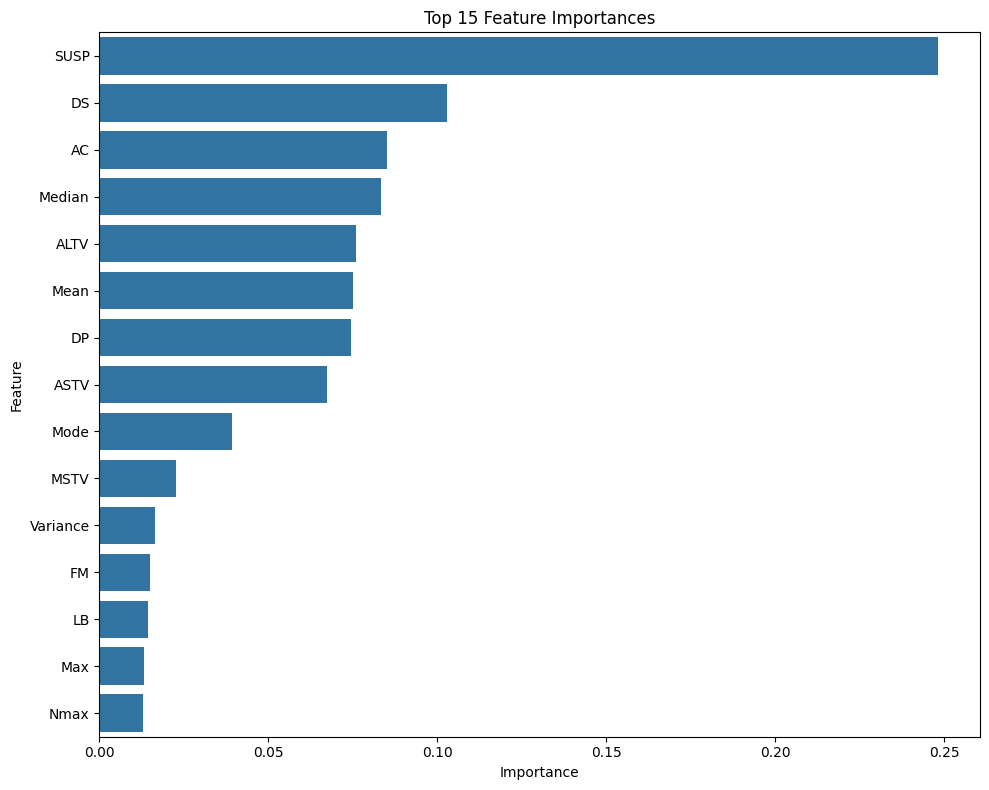

In [ ]:
feature_importance = best_xgb.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10))

# Plot feature importance
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

### Model Interpretability

After achieving strong test performance (Pathologic recall: 0.94), we analyzed which features drive the model's predictions.

**Key Findings**


---


Top 3 Features:

SUSP - Dominant feature (~0.25 importance). Expert-flagged suspect patterns are the strongest predictor.

DS (Severe Decelerations) - Sharp heart rate drops indicate oxygen deprivation.

AC (Accelerations) - Heart rate spikes signal fetal well-being.

**Clinical Validation**


---

The model prioritizes the same patterns clinicians watch for: dangerous decelerations and reassuring accelerations. This alignment confirms the model learns medically meaningful patterns, not noise.

# Save the tuned XGBoost model

In [ ]:
import joblib

joblib.dump(best_xgb, "xgb_ctg_tuned_model.joblib")


['xgb_ctg_tuned_model.joblib']

In [ ]:
joblib.dump(scaler, "ctg_scaler.joblib")

['ctg_scaler.joblib']

In [ ]:
joblib.dump(X_train.columns.tolist(), "ctg_features.joblib")

['ctg_features.joblib']